In [1]:
from lsst.daf.butler import Butler
from useful_functions_global import *
import pandas as pd
import numpy as np
import healpy as hp
from astropy.table import Table, vstack
import fitsio
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u

In [2]:
## check just one particular tract for now
## all the tracts have patches 0-99 (10 x 10 = 100 patches)

repo = "dp2_prep"
skymap = 'lsst_cells_v2'
field = 'edfs'
tract = 2394
patch = 10

#### Dataset Types available in Dan's collection

for datasetType in registry.queryDatasetTypes():
    if registry.queryDatasets(datasetType, collections=dan_collection).any(execute=False, exact=False):
        if "match" in datasetType.name:
            print(datasetType)
        elif "euclid" in datasetType.name:
            print(datasetType)
        elif "object" in datasetType.name:
            print(datasetType)


DatasetType('object', {skymap, tract}, ArrowAstropy)  
DatasetType('object_nonprimary', {skymap, tract}, ArrowAstropy)  
DatasetType('object_column_validate_metrics', {skymap, tract}, MetricMeasurementBundle)  
DatasetType('euclid_q1', {skymap, tract}, ArrowAstropy)  
DatasetType('rc2_object_hsc', {skymap, tract}, ArrowAstropy)  
DatasetType('match_object_to_euclid_config', {}, Config)  
DatasetType('match_object_to_euclid_log', {skymap}, ButlerLogRecords)  
DatasetType('match_object_to_euclid_metadata', {skymap}, TaskMetadata)  
DatasetType('match_ref_euclid_q1_object', {skymap, tract}, ArrowAstropy)  
DatasetType('match_target_euclid_q1_object', {skymap, tract}, ArrowAstropy)  
DatasetType('matched_euclid_q1_object', {skymap, tract}, ArrowAstropy)

for col in DM_catalog.columns:
    if '_ra' in col:
        print(col)
    elif '_dec' in col:
        print(col)
    elif 'RIGHT_ASCENSION' in col:
        print(col)
    elif 'DECLINATION' in col:
        print(col)

There's also ra and dec available for every band (don't know the difference between those and coord_ra, coord_dec)(gonna guess I should use the latter)

#### Load in the object catalog from his matched collection
(I think this is the matched catalog)  
**$\star!!$** check the difference between object, match_ref_euclid_q1_object, match_target_euclid_q1_object, matched_euclid_q1_object

In [3]:
dan_collection = [f'u/dtaranu/DM-50135/DP2/v30_0_8/matched_{field}']
butler1 = Butler(repo, collections=dan_collection)
registry1=butler1.registry
DM_object = butler1.get('object', 
                        dataId={'skymap': skymap, 'tract': tract, 'patch' : patch}, 
                        collections=dan_collection,
                                )
print("Dan's object catalog has ", len(DM_object), " objects")

Dan's object catalog has  663543  objects


In [36]:
for col in DM_object.columns:
    if 'extend' in col:
        print(col)

g_extendedness
g_extendedness_flag
i_extendedness
i_extendedness_flag
r_extendedness
r_extendedness_flag
y_extendedness
y_extendedness_flag
z_extendedness
z_extendedness_flag
u_extendedness
u_extendedness_flag
u_model_extendedness
g_model_extendedness
r_model_extendedness
i_model_extendedness
z_model_extendedness
y_model_extendedness
griz_model_extendedness


In [4]:
my_merged_catalog = pd.read_parquet('euclid_data/q1/2394_dp2_euclid_merged.parquet', engine='fastparquet')
print("My merged catalog from butler_euclid_merge script has ", len(my_merged_catalog), " objects")

My merged catalog from butler_euclid_merge script has  64228  objects


#### Load in the object catalog from either collection Miranda sent me or the one I was using previously

In [5]:
dp2_collection = ['LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage1', ## Miranda suggested collection
                  'LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage2',
                  'LSSTCam/runs/DRP/DP2/v30_0_6_rc1/DM-53881/stage3',
                  'LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage4']

my_collection = ["LSSTCam/runs/DRP/20250515-20251214/v30_0_0_rc2/DM-53697"] ## not tied to this one, just the one I was using in the other script

butler2 = Butler(repo, collections=dp2_collection)
registry2=butler2.registry
new_object = butler2.get('object', 
                        dataId={'skymap': skymap, 'tract': tract, 'patch' : patch}, 
                        collections=dp2_collection,
                                )
butler3 = Butler(repo, collections=my_collection)
registry3=butler3.registry
my_object = butler3.get('object', 
                        dataId={'skymap': skymap, 'tract': tract, 'patch' : patch}, 
                        collections=my_collection,
                                )
print("[Collection Miranda was using for images] object catalog has ", len(new_object), " objects")
print("[Collection I was using for in old script] object catalog has ", len(my_object), " objects")

[Collection Miranda was using for images] object catalog has  662758  objects
[Collection I was using for in old script] object catalog has  577188  objects


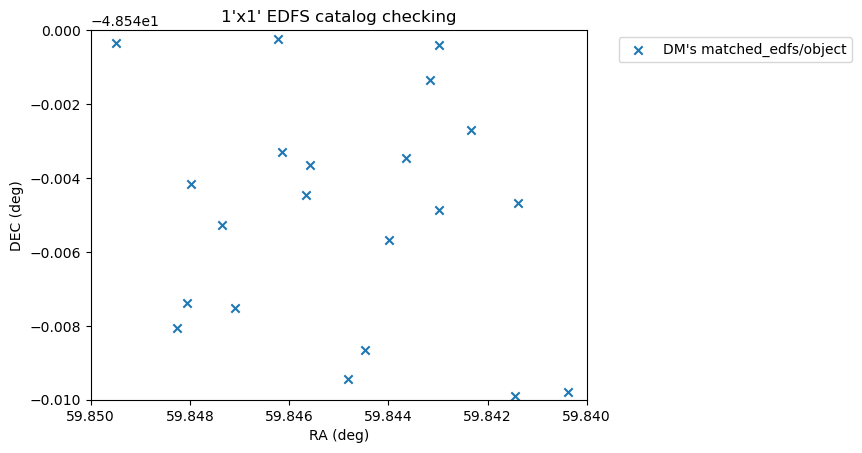

In [37]:
## first was checking the difference between all the band coordinates, not big enough for my purposes
#m = {'u': '+', 'g': 'x', 'r' : 4,'i': 5, 'z': 6, 'y': 7}
#for band in 'ugrizy':
#    plt.scatter(DM_object[f'{band}_ra'], DM_object[f'{band}_dec'], 
#            marker = m[band], label = f'{band} coord'
#           )
def restrict_to_patch(data, patch):
    data_patch = data[data['patch']==patch]
    return data_patch

my_object_patch = restrict_to_patch(my_object, 32)
DM_object_patch = restrict_to_patch(DM_object, 32)
new_object_patch = restrict_to_patch(new_object, 32)

#plt.scatter(my_object_patch[f'coord_ra'], my_object_patch[f'coord_dec'], 
#            marker = 'o', facecolors='none', edgecolors = 'C0', label = "Previously used collection")
plt.scatter(DM_object_patch[f'coord_ra'], DM_object_patch[f'coord_dec'], 
            marker = 'x', label = "DM's matched_edfs/object")
#plt.scatter(new_object_patch[f'coord_ra'], new_object_patch[f'coord_dec'], 
#            marker = '+', label = "New collection, no quality cuts")
plt.xlim(59.85, 59.84)
plt.xlabel('RA (deg)')
plt.ylim(-48.55,-48.54)
plt.ylabel('DEC (deg)')
#plt.colorbar()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("1'x1' EDFS catalog checking")
plt.show()

#### Ok now that I think this collection is at least passable to use, see how cuts affect it
I think the one I was using before just is missing a lot of sources, perhaps outdated

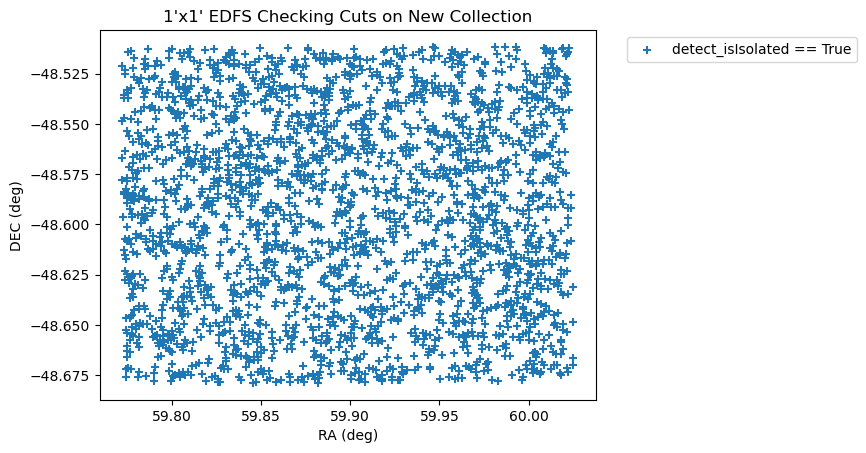

In [26]:
## detect_isIsolated == True check
detect_isIsolated_mask = (new_object_patch['detect_isIsolated'] == True)
detect_isIsolated_cut = new_object_patch[detect_isIsolated_mask]
plt.scatter(detect_isIsolated_cut[f'coord_ra'], detect_isIsolated_cut[f'coord_dec'], 
            marker = '+', color = 'C0', label = "detect_isIsolated == True")
#plt.xlim(59.85, 59.84)
plt.xlabel('RA (deg)')
#plt.ylim(-48.55,-48.54)
plt.ylabel('DEC (deg)')
#plt.colorbar()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("1'x1' EDFS Checking Cuts on New Collection")
plt.show()

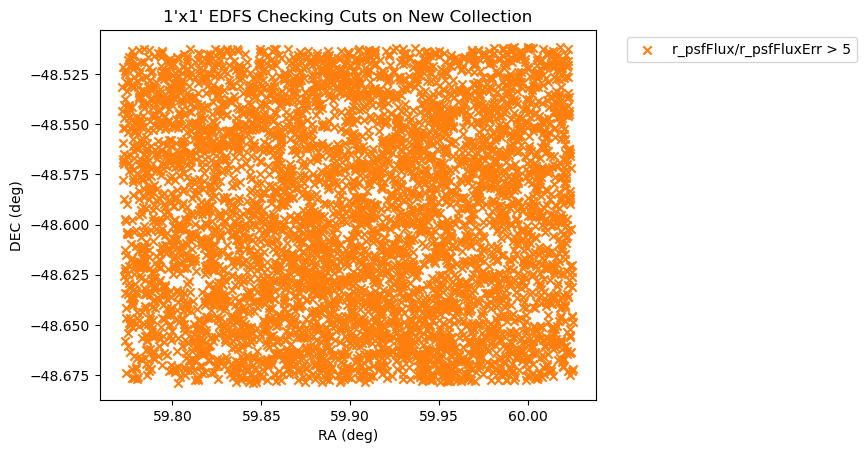

In [27]:
## r band S/N > 5 check
rSN_mask = (new_object_patch['r_psfFlux']/new_object_patch['r_psfFluxErr'] > 5)
rSN_cut = new_object_patch[rSN_mask]
plt.scatter(rSN_cut[f'coord_ra'], rSN_cut[f'coord_dec'], 
            marker = 'x', color = 'C1', label = "r_psfFlux/r_psfFluxErr > 5")
#plt.xlim(59.85, 59.84)
plt.xlabel('RA (deg)')
#plt.ylim(-48.55,-48.54)
plt.ylabel('DEC (deg)')
#plt.colorbar()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("1'x1' EDFS Checking Cuts on New Collection")
plt.show()

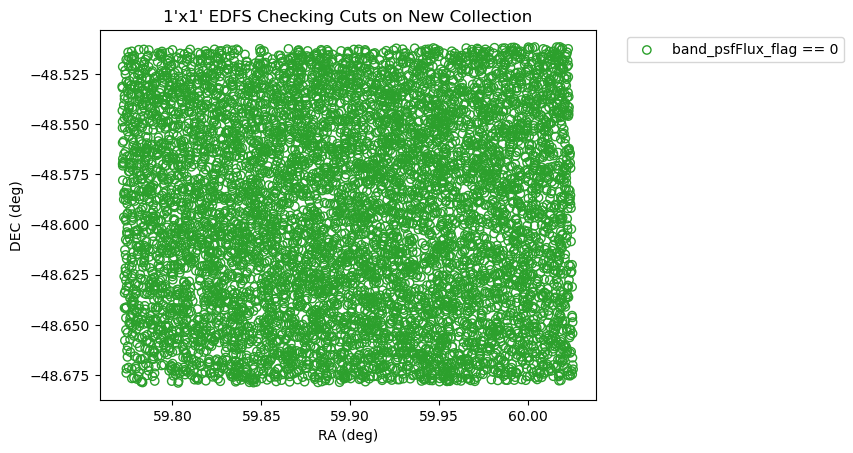

In [31]:
## band flux flag check

bands = 'griz'
band_flag_mask = None
for band in bands:
    #print(band, new_object_patch[f'{band}_psfFlux'][0])
    if band_flag_mask is None:
        band_flag_mask = (new_object_patch[f'{band}_psfFlux_flag'] == 0)
    else:
        band_flag_mask &= (new_object_patch[f'{band}_psfFlux_flag'] == 0)
band_flag_cut = new_object_patch[band_flag_mask]

plt.scatter(band_flag_cut[f'coord_ra'], band_flag_cut[f'coord_dec'], 
            marker = 'o', facecolors = 'none', edgecolors = 'C2', label = "band_psfFlux_flag == 0")
#plt.xlim(59.85, 59.84)
plt.xlabel('RA (deg)')
#plt.ylim(-48.55,-48.54)
plt.ylabel('DEC (deg)')
#plt.colorbar()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("1'x1' EDFS Checking Cuts on New Collection")
plt.show()

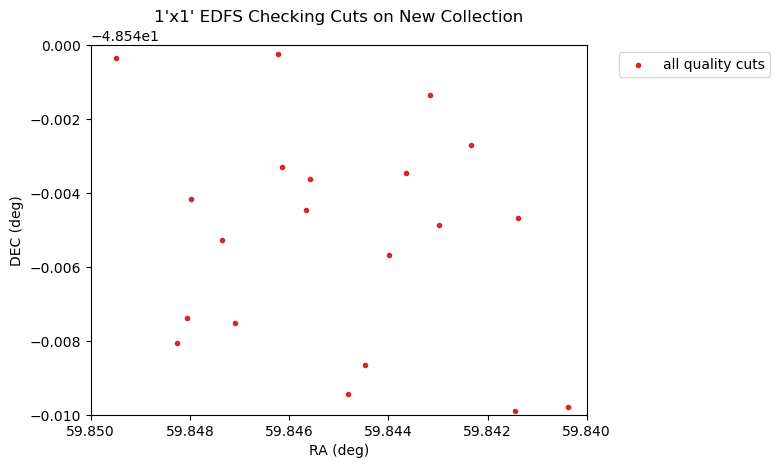

In [34]:
## mix em all together
new_object_cut = new_object_patch[detect_isIsolated_mask & rSN_mask & band_flag_mask]
plt.scatter(band_flag_cut[f'coord_ra'], band_flag_cut[f'coord_dec'], 
            marker = '.', color = 'C3', label = "all quality cuts")
plt.xlim(59.85, 59.84)
plt.xlabel('RA (deg)')
plt.ylim(-48.55,-48.54)
plt.ylabel('DEC (deg)')
#plt.colorbar()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("1'x1' EDFS Checking Cuts on New Collection")
plt.show()